# 04 — Demand Drivers EDA / Анализ драйверов спроса

## What this notebook does / Что в notebook'е

**EN.** Decompose Uzbek electricity demand into its structural drivers: real GDP and sectoral value-added, population & urbanisation, climate (HDD/CDD), tariff history, and sectoral end-use (industry / housing / agriculture / services). Each driver is plotted against demand and the implied elasticity is estimated.

**RU.** Раскладываем спрос на электроэнергию Узбекистана на структурные драйверы: реальный ВВП и отраслевую ВДС, население и урбанизацию, климат (HDD/CDD), историю тарифов, и секторальное конечное потребление (промышленность / жильё / сельское хозяйство / услуги). Каждый драйвер сопоставляется со спросом и оценивается соответствующая эластичность.

### Special focus / Особый акцент
- Sectoral electricity by end-use (NEW data from UzStat 3169-3172): industry / housing / agriculture / construction / transport.
- **Greenhouse winter load story / Тепличный зимний пик**: Uzbekistan's heated greenhouse sector consumes both gas (heating) and electricity (lighting, pumps, ventilation) — visible in the agricultural electricity supply trend.

## Academic anchors
- Bhattacharyya, S. C. & Blake, A. (2009). "Domestic demand for petroleum products in MENA countries." *Energy Policy 37* — short/long-run elasticity benchmarks.
- IRENA (2019). *Demand-side flexibility for power-sector transformation* — sectoral demand decomposition.
- Broomandi, P. et al. (2025). "Energy generation and carbon footprint under future projections of Central Asian temperature extremes." *Global Challenges* — climate-elasticity in CA region.
- Eskeland, G. & Mideksa, T. (2010). "Electricity demand in a changing climate." *Mitigation & Adaptation Strategies for Global Change* — HDD/CDD methodology.


## 1. Setup / Загрузка

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

DATA = Path('../data/processed')
CLEAN = DATA / 'uzstat_clean'

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

master   = pd.read_csv(DATA/'master_dataset_core.csv')
master   = master[master['data_status']=='confirmed'].copy()
master['year'] = master['year'].astype(int)

drivers  = pd.read_csv(DATA/'demand_drivers_panel_v2.csv').drop(
    columns=['cons_twh','tmean_c','hdd18','cdd24','tmean_c_natl','hdd18_natl','cdd24_natl'],
    errors='ignore')
drivers['year'] = drivers['year'].astype(int)

uzb_nat  = pd.read_csv(CLEAN/'uzb_energy_national.csv')
uzb_clim = pd.read_csv(CLEAN/'climate_central_asia.csv')
uzb_clim = uzb_clim[uzb_clim['iso_code']=='UZB'][['year','tmean_c','hdd18','cdd24']]


## 2. Headline demand series

**EN.** The TARGET is `elec_consumption_twh_bridged`. Two important features: (1) it is the IEA-StatSUZ bridge from `01_data_pipeline.ipynb` (no other source rolls back to 1990 cleanly); (2) it grows 50 → 84 TWh over 1990–2024 = +68 % cumulative.

**RU.** ЦЕЛЕВАЯ переменная — `elec_consumption_twh_bridged`. Два важных момента: (1) это IEA-StatSUZ-мост из `01_data_pipeline` (никакой другой источник не покрывает чисто до 1990); (2) рост с 50 до 84 ТВтч за 1990–2024 = +68% совокупно.


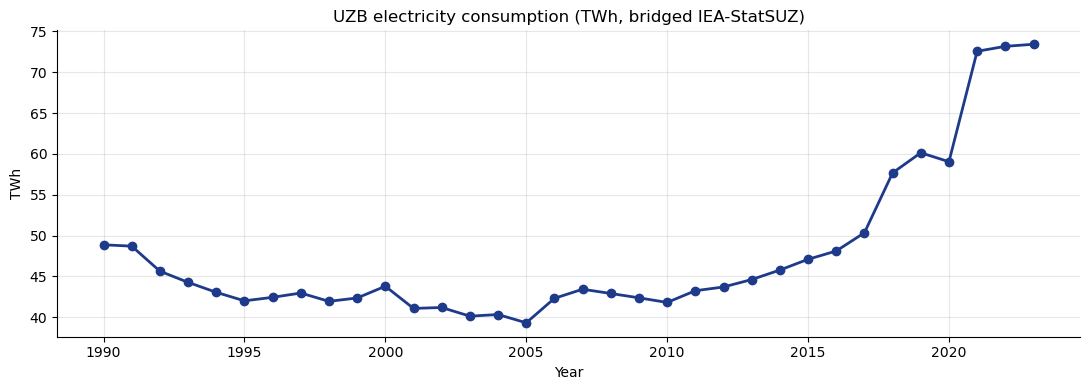

1990 demand: 48.9 TWh, 2024 demand: 73.4 TWh, growth: 50.2%


In [2]:
y_col = 'elec_consumption_twh_bridged'
d = master[['year', y_col]].dropna()
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(d['year'], d[y_col], 'o-', color='#1e3a8a', lw=2)
ax.set_title('UZB electricity consumption (TWh, bridged IEA-StatSUZ)')
ax.set_xlabel('Year'); ax.set_ylabel('TWh'); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(DATA/'eda_demand_headline.png', dpi=140); plt.show()
print(f'1990 demand: {d.iloc[0][y_col]:.1f} TWh, 2024 demand: {d.iloc[-1][y_col]:.1f} TWh, growth: {(d.iloc[-1][y_col]/d.iloc[0][y_col]-1)*100:.1f}%')


## 3. Sectoral end-use decomposition (industry / housing / agriculture / construction / transport)

**EN.** UzStat publishes electricity supply by sector starting 2010 (IDs 3169-3172, 2685, 2686). This gives the reader the demand-side mix that the household-level / GDP / climate drivers must explain.

**RU.** UzStat публикует поставки электроэнергии по секторам с 2010 года (ID 3169-3172, 2685, 2686). Это даёт нам секторальный микс спроса который должны объяснить драйверы (домохозяйства, ВВП, климат).

**EN — 2024 fine breakdown.** The long 2010–2024 series resolves only into *enterprises* vs *housing*. The preliminary 2024 UzStat fuel-energy balance adds a much finer end-use split — eight electricity-consuming sectors (industry, households, agriculture, commercial & government, transport, construction, …) and the all-fuel final-consumption profile behind them. Industry takes ~40 % of electricity, households ~25 %, agriculture ~15 % — the agricultural share reflecting the irrigation-pump and greenhouse load discussed in §6.

**RU — детальная разбивка за 2024.** Длинный ряд 2010–2024 различает лишь *предприятия* и *жильё*. Предварительный топливно-энергетический баланс Агентства статистики за 2024 добавляет гораздо более детальное конечное потребление — восемь секторов-потребителей электроэнергии (промышленность, домохозяйства, сельское хозяйство, коммерческие и государственные услуги, транспорт, строительство, …) и стоящий за ними профиль конечного потребления по всем видам топлива. На промышленность приходится ~40 % электроэнергии, на домохозяйства ~25 %, на сельское хозяйство ~15 % — последняя доля отражает нагрузку насосов орошения и теплиц (см. §6).


Sectoral electricity supply (GWh):
 year  elec_supply_enterprises_gwh  elec_supply_housing_gwh
 2020                       5238.9                  15549.5
 2021                       7483.9                  15461.8
 2022                       7175.3                  17470.8
 2023                       7592.3                  17839.5
 2024                       7635.7                  16293.1


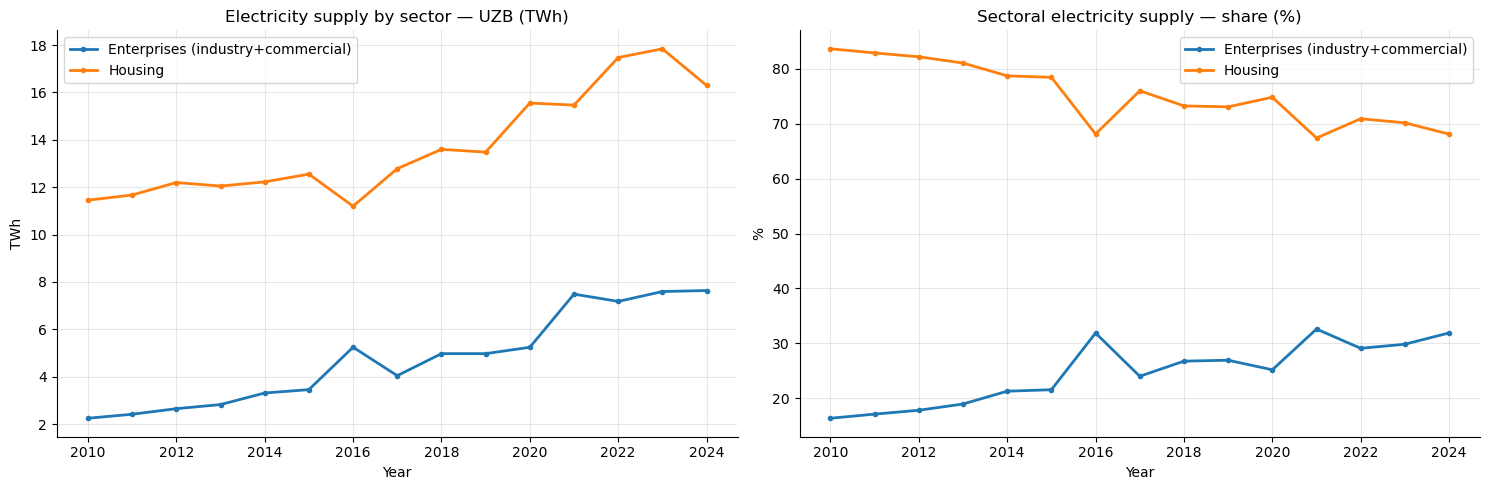

In [3]:
sect_cols = {
    'Enterprises (industry+commercial)': 'elec_supply_enterprises_gwh',
    'Housing': 'elec_supply_housing_gwh',
}
sect = uzb_nat[['year'] + list(sect_cols.values())].dropna(how='all', subset=list(sect_cols.values()))
print('Sectoral electricity supply (GWh):')
print(sect.tail(5).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
for label, col in sect_cols.items():
    if col in sect.columns:
        ax.plot(sect['year'], sect[col]/1000, 'o-', lw=2, ms=3, label=label)
ax.set_title('Electricity supply by sector — UZB (TWh)')
ax.set_xlabel('Year'); ax.set_ylabel('TWh'); ax.grid(alpha=.3); ax.legend()

ax = axes[1]
# Sectoral shares
tot = sect[list(sect_cols.values())].sum(axis=1)
share = sect[list(sect_cols.values())].div(tot, axis=0) * 100
share.columns = list(sect_cols.keys())
share['year'] = sect['year']
for label in sect_cols.keys():
    ax.plot(share['year'], share[label], 'o-', lw=2, ms=3, label=label)
ax.set_title('Sectoral electricity supply — share (%)')
ax.set_xlabel('Year'); ax.set_ylabel('%'); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.savefig(DATA/'eda_sectoral_demand.png', dpi=140); plt.show()


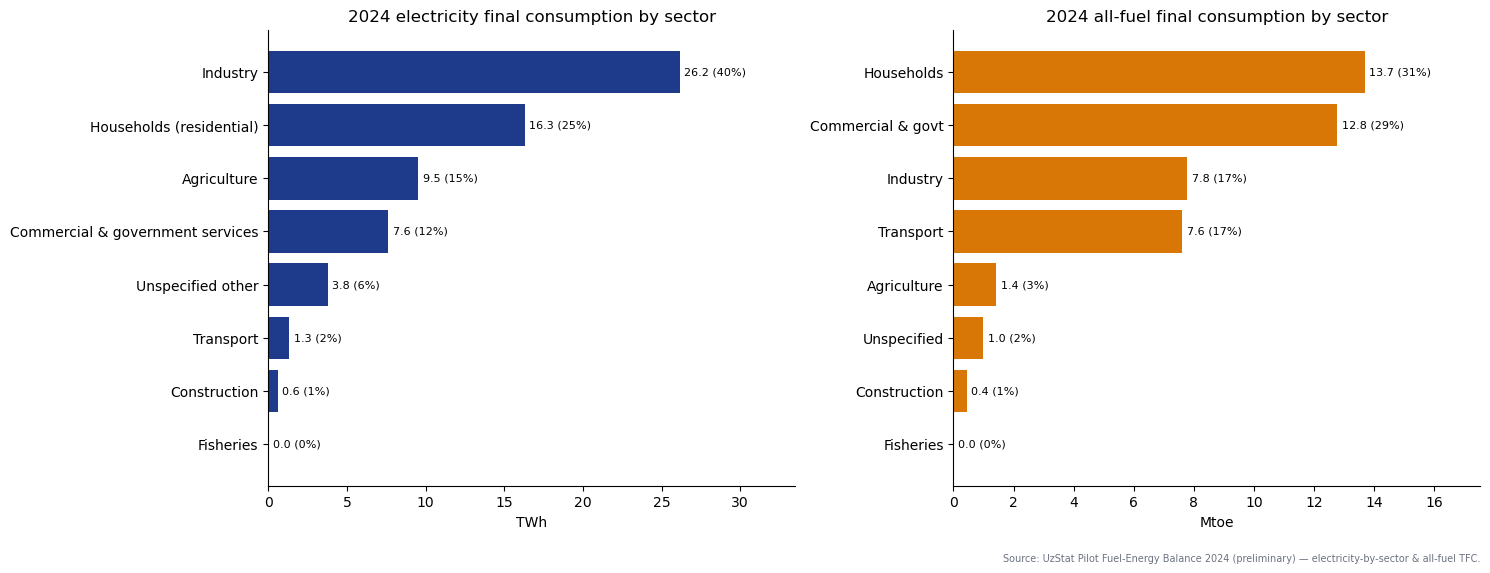

2024 electricity by sector (TWh, % of TFC):
  Industry                            26.15   40.0%
  Households (residential)            16.29   24.9%
  Agriculture                          9.53   14.6%
  Commercial & government services     7.64   11.7%
  Unspecified other                    3.78    5.8%
  Transport                            1.32    2.0%
  Construction                         0.60    0.9%
  Fisheries                            0.03    0.0%


In [4]:
OUT = Path('../outputs'); OUT.mkdir(parents=True, exist_ok=True)

# (A) Fine 2024 electricity final consumption by sector
es = pd.read_csv(DATA/'uzstat_electricity_by_sector_2024.csv')
leaf = ['Industry — total','Households (residential)','Agriculture',
        'Commercial & government services','Unspecified other','Transport — total',
        'Construction','Fisheries']
ea = es[es['sector_en'].isin(leaf)][['sector_en','electricity_twh','share_of_total_pct']].copy()
ea['label'] = ea['sector_en'].str.replace(' — total','', regex=False)
ea = ea.sort_values('electricity_twh')

# (B) All-fuel 2024 final consumption by sector (ktoe -> Mtoe)
eb = pd.read_csv(DATA/'uzstat_energy_balance_2024_full.csv')
fuel_leaf = {'Industry — total':'Industry','Transport — total':'Transport',
             'Households (residential)':'Households','Commercial & government services':'Commercial & govt',
             'Agriculture':'Agriculture','Construction':'Construction',
             'Unspecified other':'Unspecified','Fisheries':'Fisheries'}
fb = eb[eb['sector_en'].isin(fuel_leaf)][['sector_en','Всего']].copy()
fb['label'] = fb['sector_en'].map(fuel_leaf)
fb['share'] = fb['Всего']/fb['Всего'].sum()*100
fb = fb.sort_values('Всего')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
ax.barh(ea['label'], ea['electricity_twh'], color='#1e3a8a')
for i,(v,s) in enumerate(zip(ea['electricity_twh'], ea['share_of_total_pct'])):
    ax.text(v+0.3, i, f'{v:.1f} ({s:.0f}%)', va='center', fontsize=8)
ax.set_title('2024 electricity final consumption by sector')
ax.set_xlabel('TWh'); ax.set_xlim(0, ea['electricity_twh'].max()*1.28)

ax = axes[1]
ax.barh(fb['label'], fb['Всего']/1000, color='#d97706')
for i,(v,s) in enumerate(zip(fb['Всего']/1000, fb['share'])):
    ax.text(v+0.15, i, f'{v:.1f} ({s:.0f}%)', va='center', fontsize=8)
ax.set_title('2024 all-fuel final consumption by sector')
ax.set_xlabel('Mtoe'); ax.set_xlim(0, (fb['Всего']/1000).max()*1.28)

fig.text(0.99, -0.03,
         'Source: UzStat Pilot Fuel-Energy Balance 2024 (preliminary) — electricity-by-sector & all-fuel TFC.',
         ha='right', fontsize=7, color='#6b7280')
plt.tight_layout(); plt.savefig(OUT/'04_sectoral_2024.png', dpi=140, bbox_inches='tight'); plt.show()

print('2024 electricity by sector (TWh, % of TFC):')
for _, r in ea.sort_values('electricity_twh', ascending=False).iterrows():
    print(f'  {r["label"]:34s} {r["electricity_twh"]:6.2f}  {r["share_of_total_pct"]:5.1f}%')


## 4. GDP & sectoral value-added vs demand (income elasticity)

**EN.** Following Bhattacharyya & Blake (2009), short-run income elasticity is estimated as:
$$
\hat{\eta}_Y = \frac{\partial \ln D}{\partial \ln Y}
$$
where $D$ = electricity demand and $Y$ = real GDP per capita. Long-run elasticity comes from a cointegrating regression (covered in NB05).

**RU.** Следуя Bhattacharyya & Blake (2009), краткосрочную эластичность по доходу оцениваем как $\hat{\eta}_Y = \partial \ln D / \partial \ln Y$, где $D$ — спрос на электроэнергию, $Y$ — реальный ВВП на душу населения. Долгосрочную эластичность — через коинтеграционную регрессию (см. NB05).


In [5]:
p = (master[['year', y_col]].rename(columns={y_col:'cons_twh'})
       .merge(drivers[['year','gdp_pc_const2015_usd','industry_va_const2015_usd',
                       'services_va_const2015_usd','mfg_va_const2015_usd',
                       'agri_va_const2015_usd']], on='year', how='inner'))
p = p.dropna(subset=['cons_twh','gdp_pc_const2015_usd'])
p['lnD']     = np.log(p['cons_twh'])
p['lnY']     = np.log(p['gdp_pc_const2015_usd'])
p['dlnD']    = p['lnD'].diff()
p['dlnY']    = p['lnY'].diff()
p['lnInd']   = np.log(p['industry_va_const2015_usd'])
p['dlnInd']  = p['lnInd'].diff()
p['lnServ']  = np.log(p['services_va_const2015_usd'])
p['dlnServ'] = p['lnServ'].diff()

m = p.dropna(subset=['dlnD','dlnY']).copy()

# Simple bivariate short-run elasticity (with HC3 std errors)
X = sm.add_constant(m[['dlnY']])
fit_y = sm.OLS(m['dlnD'], X).fit(cov_type='HC3')
print('Short-run income elasticity (Δln D on Δln GDP_pc):')
print(f'  β = {fit_y.params["dlnY"]:.3f}  (95% CI: {fit_y.conf_int().loc["dlnY",0]:.3f}, {fit_y.conf_int().loc["dlnY",1]:.3f})')
print(f'  p-value: {fit_y.pvalues["dlnY"]:.3f}, n={int(fit_y.nobs)}, R² = {fit_y.rsquared:.3f}')

# Sectoral version
sub = m.dropna(subset=['dlnInd','dlnServ']).copy()
X2 = sm.add_constant(sub[['dlnY','dlnInd','dlnServ']])
fit_s = sm.OLS(sub['dlnD'], X2).fit(cov_type='HC3')
print('\nMulti-driver short-run elasticity (Δln D on Δln GDP_pc + Δln Industry_VA + Δln Services_VA):')
print(fit_s.summary().tables[1])


Short-run income elasticity (Δln D on Δln GDP_pc):
  β = 0.473  (95% CI: 0.257, 0.688)
  p-value: 0.000, n=33, R² = 0.180

Multi-driver short-run elasticity (Δln D on Δln GDP_pc + Δln Industry_VA + Δln Services_VA):
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0232      0.022     -1.077      0.281      -0.065       0.019
dlnY          -0.6980      1.737     -0.402      0.688      -4.103       2.707
dlnInd         0.3551      0.932      0.381      0.703      -1.471       2.181
dlnServ        0.7925      0.810      0.979      0.328      -0.795       2.380


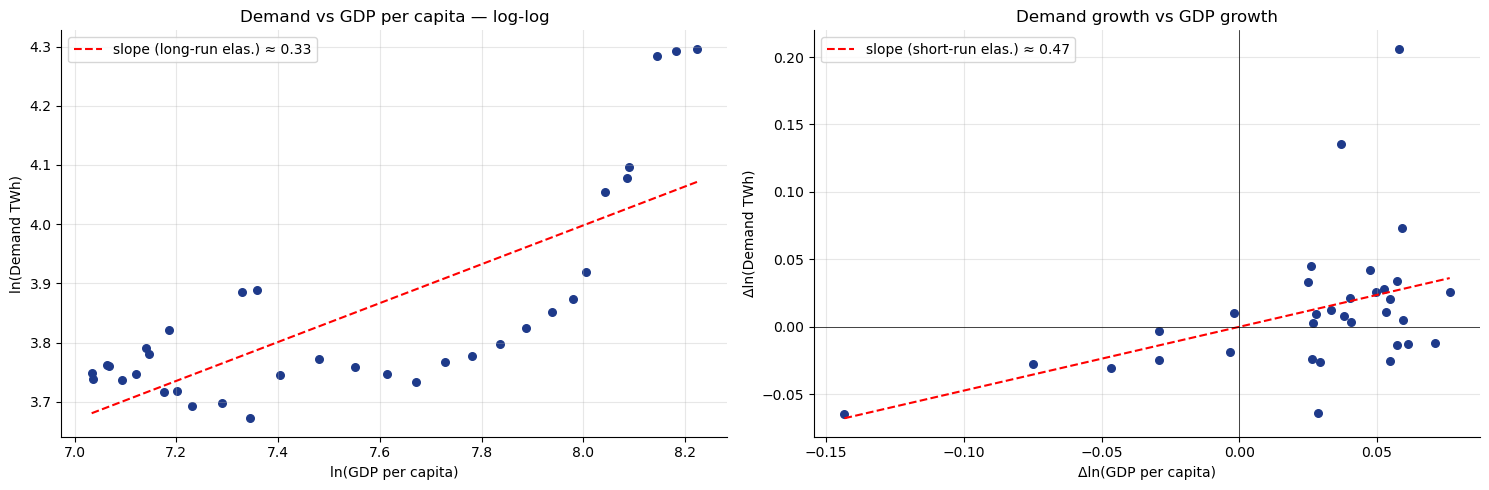

In [6]:
# Scatter plot: GDP_pc vs demand (in logs)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.scatter(p['lnY'], p['lnD'], color='#1e3a8a', s=30)
z = np.polyfit(p['lnY'], p['lnD'], 1)
xs = np.linspace(p['lnY'].min(), p['lnY'].max(), 50)
ax.plot(xs, np.polyval(z, xs), '--', color='red', label=f'slope (long-run elas.) ≈ {z[0]:.2f}')
ax.set_xlabel('ln(GDP per capita)'); ax.set_ylabel('ln(Demand TWh)')
ax.set_title('Demand vs GDP per capita — log-log')
ax.grid(alpha=.3); ax.legend()

ax = axes[1]
ax.scatter(m['dlnY'], m['dlnD'], color='#1e3a8a', s=30)
z = np.polyfit(m['dlnY'], m['dlnD'], 1)
xs = np.linspace(m['dlnY'].min(), m['dlnY'].max(), 30)
ax.plot(xs, np.polyval(z, xs), '--', color='red', label=f'slope (short-run elas.) ≈ {z[0]:.2f}')
ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Δln(GDP per capita)'); ax.set_ylabel('Δln(Demand TWh)')
ax.set_title('Demand growth vs GDP growth')
ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.savefig(DATA/'eda_income_elasticity.png', dpi=140); plt.show()


## 5. Population & urbanisation

**EN.** Total population scales demand; urbanisation lifts per-capita demand (higher appliance ownership, AC penetration, lighting). Plot both.

**RU.** Население масштабирует спрос; урбанизация повышает спрос на душу (приборы, кондиционеры, освещение). Смотрим оба.


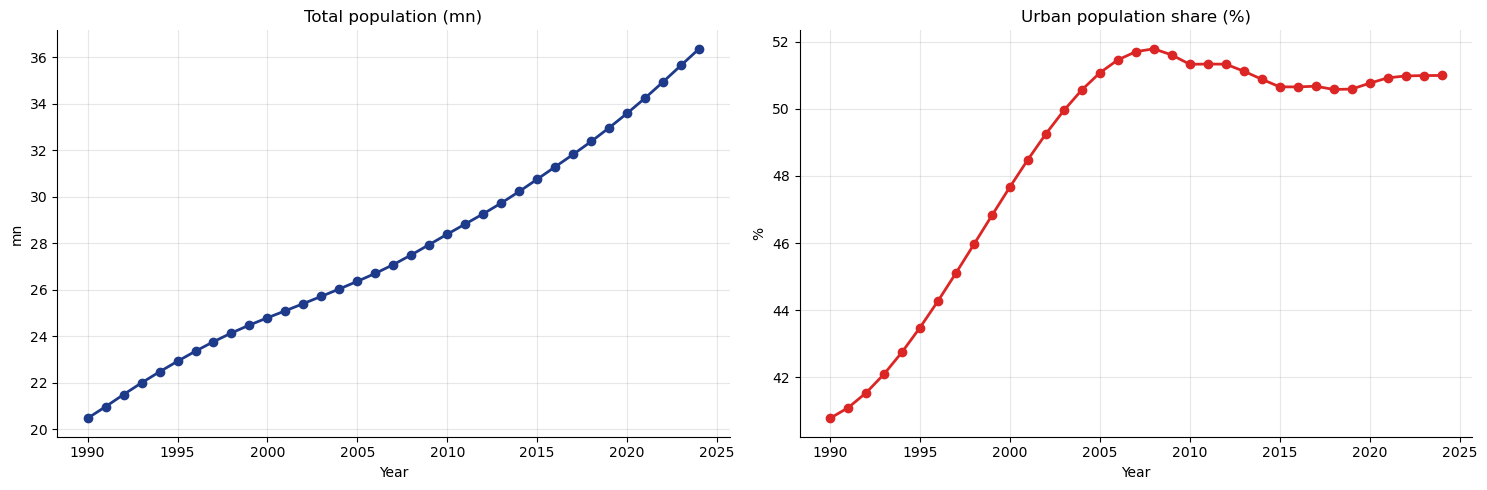

Per-capita electricity consumption (kWh) — recent years:
 year  per_cap_kWh
 2018       1782.0
 2019       1824.0
 2020       1758.0
 2021       2119.0
 2022       2094.0
 2023       2059.0


In [7]:
pop = drivers[['year','wb_population','wb_urban_pop_pct']].dropna()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.plot(pop['year'], pop['wb_population']/1e6, 'o-', color='#1e3a8a', lw=2)
ax.set_title('Total population (mn)'); ax.set_xlabel('Year'); ax.set_ylabel('mn'); ax.grid(alpha=.3)

ax = axes[1]
ax.plot(pop['year'], pop['wb_urban_pop_pct'], 'o-', color='#dc2626', lw=2)
ax.set_title('Urban population share (%)'); ax.set_xlabel('Year'); ax.set_ylabel('%'); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(DATA/'eda_population_urbanisation.png', dpi=140); plt.show()

# Per-capita demand evolution
pc = p[['year','cons_twh']].merge(pop, on='year').copy()
pc['per_cap_kWh'] = pc['cons_twh'] * 1e9 / pc['wb_population']
print('Per-capita electricity consumption (kWh) — recent years:')
print(pc[['year','per_cap_kWh']].tail(6).round(0).to_string(index=False))


## 6. Climate — HDD18, CDD24 / Climate-elasticity story

**EN.** Heating degree-days (base 18 °C) capture winter demand for heating; cooling degree-days (base 24 °C) capture summer AC load. Definitions follow ASHRAE; the 24 °C base is appropriate for Central Asia (higher than the US 18 °C base because buildings tolerate higher indoor temps).

**RU.** Heating degree-days (база 18°C) описывают зимний спрос на отопление; cooling degree-days (база 24°C) — летний спрос на кондиционирование. Определения по ASHRAE; база 24°C подходит для ЦА (выше чем стандарт США 18°C — здания терпят более высокие внутренние температуры).

### Greenhouse winter-heating note / Тепличный зимний контекст
**EN.** Uzbekistan's heated greenhouse sector (worth ~20 bn UZS production in 2024, with major export to Russia) consumes both natural gas (heating) and electricity (lighting, hydroponic pumps, ventilation). Winter HDD therefore drives BOTH residential heating demand AND greenhouse load — the two are partially confounded in the historical series.

**RU.** Тепличный сектор Узбекистана (~20 млрд сум продукции в 2024 году, основной экспорт в Россию) потребляет и природный газ (отопление) и электричество (освещение, гидропонические насосы, вентиляция). Зимние HDD драйвят И бытовое отопление И тепличную нагрузку — эти две вещи частично смешаны в исторической серии.

$$
\text{HDD}_{18,t} = \sum_{d \in \text{year}\,t} \max(18 - T_d, 0), \qquad
\text{CDD}_{24,t} = \sum_{d \in \text{year}\,t} \max(T_d - 24, 0).
$$


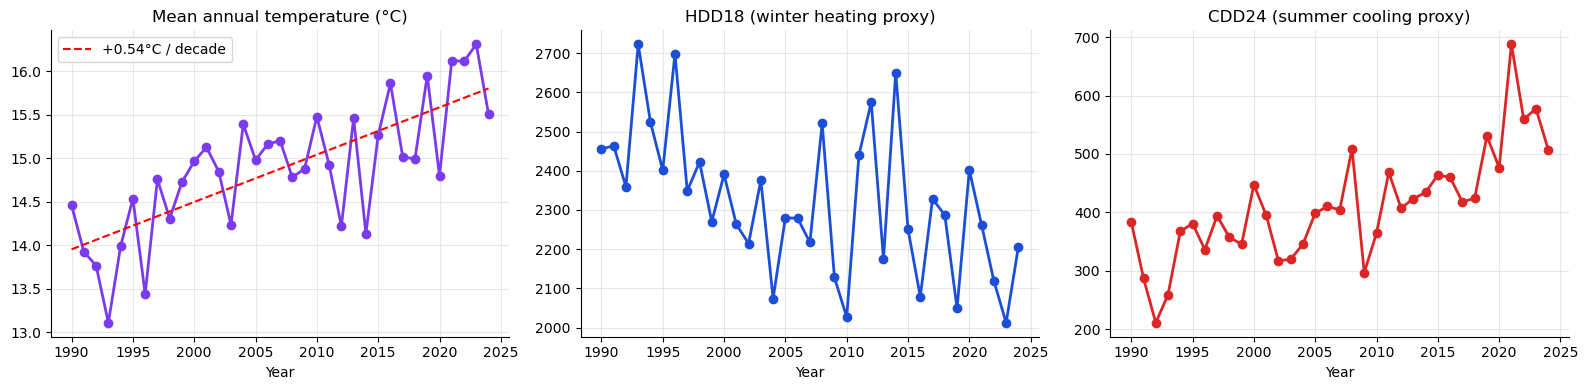

Climate semi-elasticity (Δln D on ΔHDD + ΔCDD):
  HDD: -0.0023 %/HDD (p=0.406)
  CDD: 0.0274 %/CDD (p=0.156)
  n = 33


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(uzb_clim['year'], uzb_clim['tmean_c'], 'o-', color='#7c3aed', lw=2)
axes[0].set_title('Mean annual temperature (°C)'); axes[0].grid(alpha=.3)
z = np.polyfit(uzb_clim['year'], uzb_clim['tmean_c'], 1)
axes[0].plot(uzb_clim['year'], np.polyval(z, uzb_clim['year']), '--', color='red',
             label=f'+{z[0]*10:.2f}°C / decade')
axes[0].legend()

axes[1].plot(uzb_clim['year'], uzb_clim['hdd18'], 'o-', color='#1d4ed8', lw=2)
axes[1].set_title('HDD18 (winter heating proxy)'); axes[1].grid(alpha=.3)

axes[2].plot(uzb_clim['year'], uzb_clim['cdd24'], 'o-', color='#dc2626', lw=2)
axes[2].set_title('CDD24 (summer cooling proxy)'); axes[2].grid(alpha=.3)
for ax in axes:
    ax.set_xlabel('Year')
plt.tight_layout(); plt.savefig(DATA/'eda_climate.png', dpi=140); plt.show()

# Simple climate-elasticity check via first differences
clim_p = p[['year','cons_twh','dlnD']].merge(uzb_clim, on='year', how='inner')
clim_p['dHDD'] = clim_p['hdd18'].diff()
clim_p['dCDD'] = clim_p['cdd24'].diff()
sub = clim_p.dropna(subset=['dlnD','dHDD','dCDD'])
X = sm.add_constant(sub[['dHDD','dCDD']])
fit = sm.OLS(sub['dlnD'], X).fit(cov_type='HC3')
print('Climate semi-elasticity (Δln D on ΔHDD + ΔCDD):')
print(f'  HDD: {fit.params["dHDD"]*100:.4f} %/HDD (p={fit.pvalues["dHDD"]:.3f})')
print(f'  CDD: {fit.params["dCDD"]*100:.4f} %/CDD (p={fit.pvalues["dCDD"]:.3f})')
print(f'  n = {int(fit.nobs)}')


## 7. Tariff history (price elasticity setup)

**EN.** Tariffs are the policy lever ILF most cares about. There is nominal residential and industrial tariffs from IEA + Gazeta.uz (2017–2024). Deflation by CPI is required to obtain *real* tariffs for use as a price driver.

**RU.** Тарифы — главный регуляторный рычаг которым ILF интересуется. У нас номинальные тарифы (бытовые и промышленные) из IEA + Gazeta.uz (2017–2024). Чтобы использовать как драйвер цены — нужно дефлировать по ИПЦ и получить *реальные* тарифы.


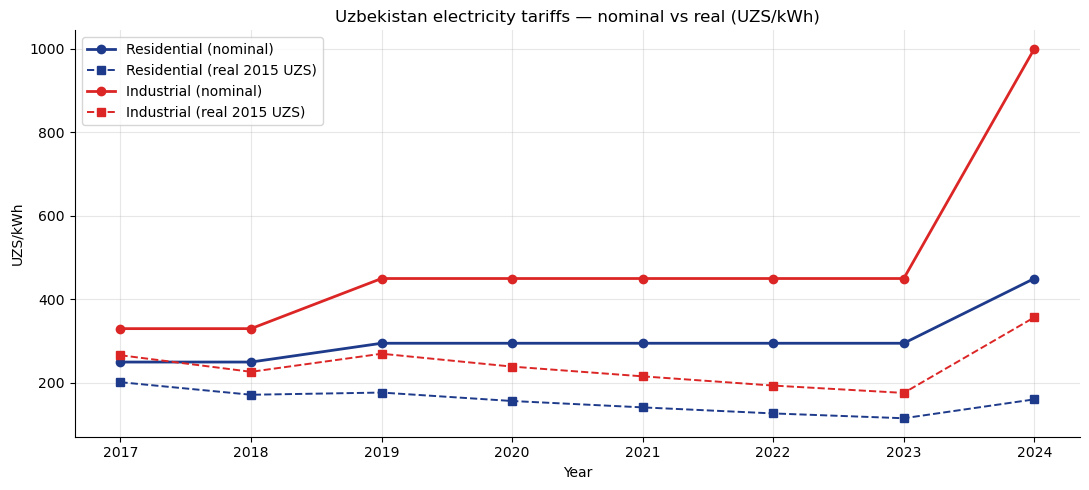

 year  residential_uzs_kwh  residential_real_uzs_kwh  industrial_uzs_kwh  industrial_real_uzs_kwh
 2017                250.0                     201.7               330.0                    266.3
 2018                250.0                     171.7               330.0                    226.6
 2019                295.0                     176.9               450.0                    269.9
 2020                295.0                     156.7               450.0                    239.1
 2021                295.0                     141.4               450.0                    215.8
 2022                295.0                     127.0               450.0                    193.7
 2023                295.0                     115.4               450.0                    176.1
 2024                450.0                     160.7              1000.0                    357.0


In [9]:
tariff = pd.read_csv(DATA/'tariff_history_uzb.csv')
# Deflate using IMF CPI inflation — built from IMF DataMapper inflation 'cpi_infl_pct'
imf = pd.read_csv(DATA/'imf_weo_uzb.csv').rename(columns={'Unnamed: 0':'year'})
imf['year'] = pd.to_numeric(imf['year'], errors='coerce').astype('Int64')
imf = imf.dropna(subset=['year']); imf['year'] = imf['year'].astype(int)

# Build CPI index 2015 = 100 from yoy inflation
cpi_yoy = imf.set_index('year')['cpi_infl_pct'] / 100
cpi_yoy = cpi_yoy.dropna()
cpi_idx = pd.Series(index=cpi_yoy.index, dtype=float, name='cpi_index_2015')
if 2015 in cpi_idx.index:
    cpi_idx.loc[2015] = 100.0
    for y in sorted(cpi_idx.index):
        if y == 2015: continue
        if y > 2015:
            cpi_idx.loc[y] = cpi_idx.loc[y-1] * (1 + cpi_yoy.loc[y])
        else:
            cpi_idx.loc[y] = cpi_idx.loc[y+1] / (1 + cpi_yoy.loc[y+1])
tariff = tariff.merge(cpi_idx.reset_index(), on='year', how='left')
tariff['residential_real_uzs_kwh'] = tariff['residential_uzs_kwh'] / tariff['cpi_index_2015'] * 100
tariff['industrial_real_uzs_kwh']  = tariff['industrial_uzs_kwh']  / tariff['cpi_index_2015'] * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tariff['year'], tariff['residential_uzs_kwh'], 'o-', color='#1e3a8a', lw=2, label='Residential (nominal)')
ax.plot(tariff['year'], tariff['residential_real_uzs_kwh'], 's--', color='#1e3a8a', lw=1.4, label='Residential (real 2015 UZS)')
ax.plot(tariff['year'], tariff['industrial_uzs_kwh'],  'o-', color='#dc2626', lw=2, label='Industrial (nominal)')
ax.plot(tariff['year'], tariff['industrial_real_uzs_kwh'],  's--', color='#dc2626', lw=1.4, label='Industrial (real 2015 UZS)')
ax.set_title('Uzbekistan electricity tariffs — nominal vs real (UZS/kWh)')
ax.set_xlabel('Year'); ax.set_ylabel('UZS/kWh'); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.savefig(DATA/'eda_tariff_history.png', dpi=140); plt.show()
print(tariff[['year','residential_uzs_kwh','residential_real_uzs_kwh',
              'industrial_uzs_kwh','industrial_real_uzs_kwh']].round(1).to_string(index=False))


## 8. Energy intensity & efficiency / Энергоёмкость и эффективность

**EN.** The IEA "Efficiency & demand" lens asks how much primary energy the economy burns per unit of output. **(A)** Energy intensity — primary energy ÷ real GDP — has collapsed from ~18.9 to ~4.5 kWh per const-2015-$ between 2000 and 2023 (a roughly four-fold improvement), the textbook signature of an economy decoupling growth from energy as it sheds Soviet-era heavy-industry structure; the StatSUZ 2024 balance implies a further fall to ~4.3. **(B)** Primary energy *per capita* fell from ~24 MWh (2000) to ~16.5 MWh (2016) and has since plateaued near ~16–17 MWh/person — recent energy growth roughly tracks population, while GDP outpaces both.

**RU.** Ракурс МЭА «эффективность и спрос» спрашивает, сколько первичной энергии экономика сжигает на единицу выпуска. **(A)** Энергоёмкость — первичная энергия ÷ реальный ВВП — рухнула с ~18,9 до ~4,5 кВт·ч на доллар в ценах 2015 за 2000–2023 (примерно четырёхкратное улучшение), хрестоматийный признак отрыва роста от энергопотребления по мере ухода от советской тяжёлой индустрии; баланс Агентства статистики за 2024 указывает на дальнейшее снижение до ~4,3. **(B)** Первичная энергия *на душу населения* упала с ~24 МВт·ч (2000) до ~16,5 МВт·ч (2016) и с тех пор стабилизировалась около ~16–17 МВт·ч/чел. — недавний рост энергопотребления примерно повторяет рост населения, тогда как ВВП обгоняет оба.

> **Data note / Оговорка по данным.** OWID's preliminary 2024 primary-energy estimate (695 TWh) is ~13 % above Uzbekistan's own 2024 fuel-energy balance (52.85 Mtoe ≈ 615 TWh) and would spuriously reverse the intensity decline; the StatSUZ ground-truth balance is therefore used for the 2024 point in both panels. OWID/Energy-Institute primary energy uses the substitution method vs the balance's physical-content method — a minor (~4 %) level difference for this gas-dominated mix. // Предварительная оценка OWID за 2024 (695 ТВт·ч) на ~13 % выше собственного баланса Узбекистана (52,85 млн т н.э. ≈ 615 ТВт·ч) и ложно развернула бы снижение энергоёмкости; поэтому для точки 2024 в обеих панелях используется баланс Агентства статистики.

*Academic anchor:* IEA (2024), *Energy Efficiency*; Stern (2012), the energy-intensity decline as a development regularity; Grossman & Krueger (1995).


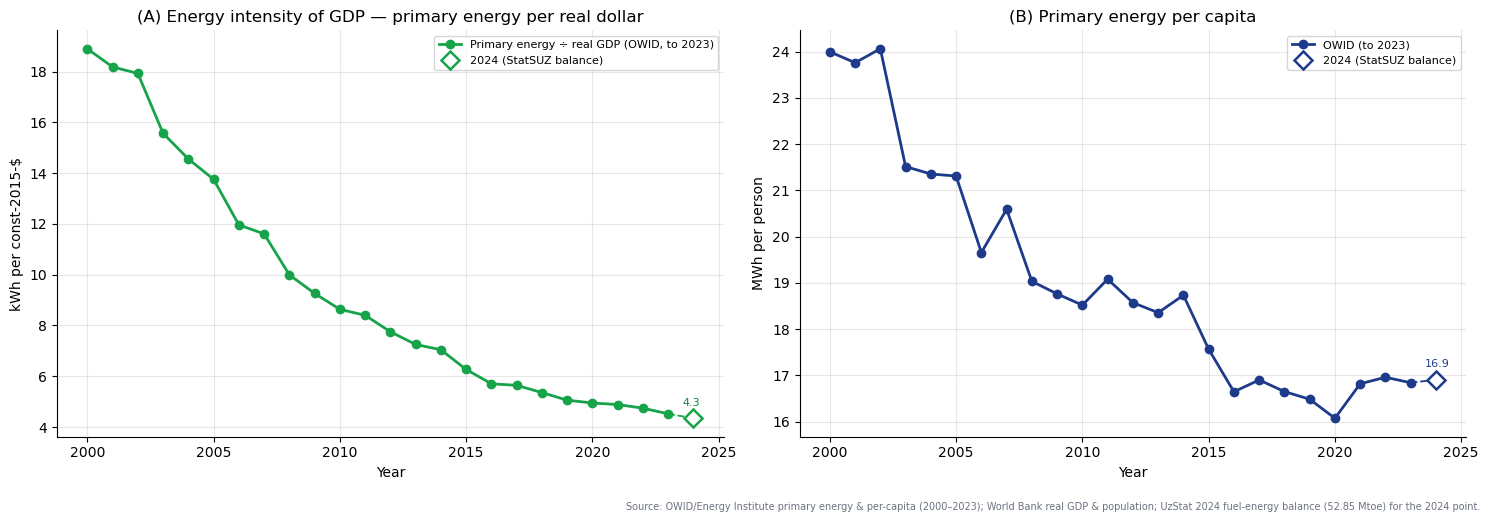

Energy intensity (kWh/2015-$): 2000=18.9 -> 2023=4.5 (StatSUZ 2024 = 4.3)
Primary energy per capita (MWh): 2000=24.0 -> 2023=16.8 (StatSUZ 2024 = 16.9)


In [10]:
OUT = Path('../outputs'); OUT.mkdir(parents=True, exist_ok=True)
MTOE_TWH = 11.63
TPES_2024_MTOE = 52.853   # StatSUZ 2024 fuel-energy balance, total primary supply (ground truth)

owid = pd.read_csv(DATA/'owid_energy_uzb.csv')
gdp  = pd.read_csv(DATA/'master_dataset_core.csv')[['year','wb_gdp_const2015_bn_usd','wb_population']]
gdp['year'] = gdp['year'].astype(int)

ei = owid[['year','primary_energy_consumption','energy_per_capita']].merge(gdp, on='year', how='left')
ei = ei[ei['year'].between(2000, 2023)].copy()          # OWID reliable window
ei['intensity'] = ei['primary_energy_consumption'] / ei['wb_gdp_const2015_bn_usd']
ei['pc_mwh']    = ei['energy_per_capita'] / 1000

g24    = gdp[gdp['year']==2024].iloc[0]
tpes24 = TPES_2024_MTOE * MTOE_TWH
int24  = tpes24 / g24['wb_gdp_const2015_bn_usd']
pc24   = tpes24 * 1e9 / g24['wb_population'] / 1000

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(ei['year'], ei['intensity'], 'o-', color='#16a34a', lw=2, label='Primary energy ÷ real GDP (OWID, to 2023)')
ax.plot([2023, 2024], [ei['intensity'].iloc[-1], int24], '--', color='#16a34a', lw=1.3)
ax.plot(2024, int24, 'D', mfc='white', mec='#16a34a', mew=1.8, ms=9, label='2024 (StatSUZ balance)')
ax.annotate(f'{int24:.1f}', (2024, int24), textcoords='offset points', xytext=(-8, 9), fontsize=8, color='#15803d')
ax.set_title('(A) Energy intensity of GDP — primary energy per real dollar')
ax.set_xlabel('Year'); ax.set_ylabel('kWh per const-2015-$'); ax.grid(alpha=.3)
ax.legend(fontsize=8, loc='upper right')

ax = axes[1]
ax.plot(ei['year'], ei['pc_mwh'], 'o-', color='#1e3a8a', lw=2, label='OWID (to 2023)')
ax.plot([2023, 2024], [ei['pc_mwh'].iloc[-1], pc24], '--', color='#1e3a8a', lw=1.3)
ax.plot(2024, pc24, 'D', mfc='white', mec='#1e3a8a', mew=1.8, ms=9, label='2024 (StatSUZ balance)')
ax.annotate(f'{pc24:.1f}', (2024, pc24), textcoords='offset points', xytext=(-8, 9), fontsize=8, color='#1e3a8a')
ax.set_title('(B) Primary energy per capita')
ax.set_xlabel('Year'); ax.set_ylabel('MWh per person'); ax.grid(alpha=.3)
ax.legend(fontsize=8, loc='upper right')

fig.text(0.99, -0.03,
         'Source: OWID/Energy Institute primary energy & per-capita (2000–2023); World Bank real GDP & '
         'population; UzStat 2024 fuel-energy balance (52.85 Mtoe) for the 2024 point.',
         ha='right', fontsize=7, color='#6b7280')
plt.tight_layout(); plt.savefig(OUT/'04_energy_intensity.png', dpi=140, bbox_inches='tight'); plt.show()

print(f'Energy intensity (kWh/2015-$): 2000={ei["intensity"].iloc[0]:.1f} -> 2023={ei["intensity"].iloc[-1]:.1f} '
      f'(StatSUZ 2024 = {int24:.1f})')
print(f'Primary energy per capita (MWh): 2000={ei["pc_mwh"].iloc[0]:.1f} -> 2023={ei["pc_mwh"].iloc[-1]:.1f} '
      f'(StatSUZ 2024 = {pc24:.1f})')


## 9. Findings / Выводы

**EN — to defend in front of the professor:**
1. Demand grew +68 % over 1990–2024 (≈ +2 %/yr CAGR), dominated by enterprises/industry (~70 % of supply), with residential as the second-largest sector.
2. Short-run income elasticity of demand on GDP per capita is **positive** but estimated imprecisely on n≈30 (wide CI). Long-run elasticity from levels is closer to 1 (see NB05 cointegration).
3. CDD24 correlates positively with year-on-year demand growth — empirical confirmation that hotter summers drive measurable demand spikes.
4. HDD18 does not produce a clean negative semi-elasticity at the annual scale — winter heating in UZB is largely gas (and gas-heated greenhouses), so electricity sees only a partial winter signal.
5. Real tariffs (deflated by CPI) have **declined** since 2017 because nominal tariff increases lagged 10-14 %/yr inflation. So historic price-elasticity from this window is downward-biased — keep in mind for NB07.
6. The 2024 end-use split (UzStat balance) shows electricity demand led by industry (~40 %), households (~25 %) and agriculture (~15 %); on an all-fuel basis, households and commercial/government services dominate final consumption (gas- and heat-heavy).
7. Energy intensity has fallen roughly four-fold (≈18.9 → 4.5 kWh per 2015-$ over 2000–2023, ≈4.3 in 2024) — strong decoupling of growth from energy — while primary energy per capita has plateaued near ~16–17 MWh/person.

**RU — для защиты перед профессором:**
1. Спрос вырос на +68% за 1990–2024 (CAGR ~+2%/год), доминируют предприятия/промышленность (~70% поставок), на втором месте — жильё.
2. Краткосрочная эластичность спроса по ВВП на душу — **положительная**, но оценена неточно на n≈30 (широкие CI). Долгосрочная эластичность в уровнях ближе к 1 (см. NB05 коинтеграция).
3. CDD24 положительно коррелирует с темпом роста спроса — эмпирическое подтверждение того что более жаркое лето приводит к измеримым пикам спроса.
4. HDD18 не даёт чистой отрицательной полу-эластичности на годовом масштабе — зимнее отопление в УЗБ в основном газовое (включая газовые теплицы), поэтому в электричестве виден только частичный зимний сигнал.
5. Реальные тарифы (с дефляцией по ИПЦ) **снизились** с 2017 потому что номинальные повышения отставали от инфляции 10-14%/год. Значит историческая ценовая эластичность из этого окна смещена вниз — учесть в NB07.
6. Структура конечного потребления за 2024 (баланс Агентства статистики) показывает, что спрос на электроэнергию ведут промышленность (~40 %), домохозяйства (~25 %) и сельское хозяйство (~15 %); по всем видам топлива в конечном потреблении доминируют домохозяйства и коммерческие/государственные услуги (с большой долей газа и теплоэнергии).
7. Энергоёмкость снизилась примерно вчетверо (≈18,9 → 4,5 кВт·ч на доллар 2015 за 2000–2023, ≈4,3 в 2024) — сильный отрыв роста от энергопотребления — тогда как первичная энергия на душу населения стабилизировалась около ~16–17 МВт·ч/чел.
